In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the Dataset
customer_df = pd.read_csv("FinTrust_Customer_Data.csv")
print(customer_df.shape)
transaction_df = pd.read_csv("FinTrust_Transaction_Data.csv")
print(transaction_df.shape)

(1500, 12)
(12000, 11)


In [3]:
#Change the datatype
transaction_df["Transaction_DateTime"] = pd.to_datetime(
    transaction_df["Transaction_DateTime"],
    errors="coerce"
)

In [4]:
print(transaction_df['Transaction_DateTime'].dtypes)

datetime64[ns]


In [5]:
#Combine Customer and Transaction Data
fintrust_df = transaction_df.merge(
    customer_df,
    on="Customer_ID",
    how="left"
)

In [6]:
fintrust_df.shape

(12000, 22)

In [7]:
fintrust_df.head()

,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,...,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-T000001,FT-C01135,2026-01-01 00:00:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,...,44,Female,Ibadan,Everyday,Current,50,42.9,500k-999k,Mobile App,Active
1,FT-T000002,FT-C00428,2026-01-01 00:10:00,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,...,23,Male,Lagos,Everyday,Current,50,95.0,Below 100k,Web,Active
2,FT-T000003,FT-C00469,2026-01-01 00:21:00,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,...,39,Female,Kaduna,Everyday,Current,53,64.4,100k-249k,Mobile App,Active
3,FT-T000004,FT-C01015,2026-01-01 00:32:00,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,...,50,Female,Lagos,Everyday,Current,19,61.7,100k-249k,Mobile App,Active
4,FT-T000005,FT-C00870,2026-01-01 00:43:00,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,...,58,Female,Kano,Everyday,Savings,8,76.5,100k-249k,Mobile App,Active


In [16]:
#1.Customer Segmentation Analysis
#How does transaction behaviour differ across customer segments?
#Summary
segment_analysis = (
    fintrust_df
    .groupby("Customer_Segment")
    .agg(
        Total_Customers=("Customer_ID", "nunique"),
        Total_Transactions=("Transaction_ID", "count"),
        Total_Transaction_Value=("Amount_NGN", "sum"),
        Average_Transaction_Value=("Amount_NGN", "mean")
    )
    .reset_index()
)
segment_analysis

,Customer_Segment,Total_Customers,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value
0,Everyday,711,5644,2.614589e+08,46325.110027
1,Premium,295,2361,1.077512e+08,45637.948251
2,SME,216,1706,8.379137e+07,49115.692679
3,Student,278,2289,1.074759e+08,46953.196300


In [10]:
#Transactions per customer
segment_analysis["Transactions_Per_Customer"] = (
    segment_analysis["Total_Transactions"] /
    segment_analysis["Total_Customers"]
)
segment_analysis

,Customer_Segment,Total_Customers,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value,Transactions_Per_Customer
0,Everyday,711,5644,2.614589e+08,46325.110027,7.938115
1,Premium,295,2361,1.077512e+08,45637.948251,8.003390
2,SME,216,1706,8.379137e+07,49115.692679,7.898148
3,Student,278,2289,1.074759e+08,46953.196300,8.233813


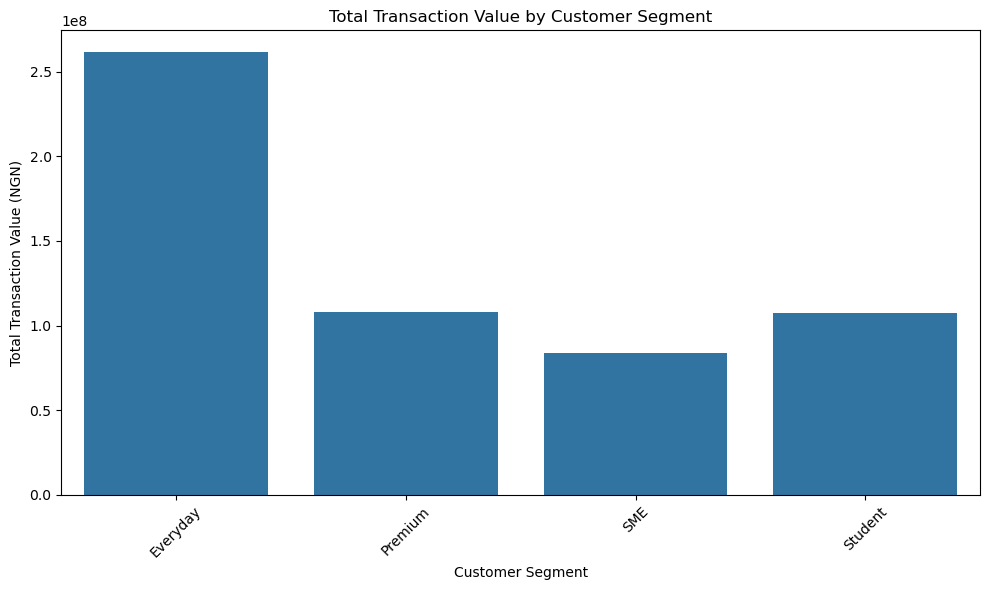

In [11]:
#Visualizations
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_analysis,
    x="Customer_Segment",
    y="Total_Transaction_Value"
)

plt.title("Total Transaction Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Transaction Value (NGN)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
#Channel Performance
#How does transaction performance differ across channels?
#Summary
channel_analysis = (
    fintrust_df
    .groupby("Channel")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Total_Transaction_Value=("Amount_NGN", "sum"),
        Average_Transaction_Value=("Amount_NGN", "mean")
    )
    .reset_index()
)
channel_analysis

,Channel,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value
0,ATM,1747,8.394235e+07,48049.430011
1,Mobile App,5102,2.401044e+08,47060.832064
2,POS,2393,1.043467e+08,43604.964994
3,USSD,889,4.275895e+07,48097.811316
4,Web,1869,8.932500e+07,47792.937368


In [14]:
#Successful Transactions
successful_by_channel = (
    fintrust_df[fintrust_df["Transaction_Status"] == "Successful"]
    .groupby("Channel")["Transaction_ID"]
    .count()
    .reset_index(name="Successful_Transactions")
)
successful_by_channel

,Channel,Successful_Transactions
0,ATM,1602
1,Mobile App,4579
2,POS,2174
3,USSD,803
4,Web,1698


In [17]:
channel_analysis = channel_analysis.merge(
    successful_by_channel,
    on="Channel",
    how="left"
)

In [19]:
channel_analysis["Success_Rate"] = (
    channel_analysis["Successful_Transactions"] /
    channel_analysis["Total_Transactions"] * 100
)
channel_analysis

,Channel,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value,Successful_Transactions,Success_Rate
0,ATM,1747,8.394235e+07,48049.430011,1602,91.700057
1,Mobile App,5102,2.401044e+08,47060.832064,4579,89.749118
2,POS,2393,1.043467e+08,43604.964994,2174,90.848308
3,USSD,889,4.275895e+07,48097.811316,803,90.326209
4,Web,1869,8.932500e+07,47792.937368,1698,90.850722


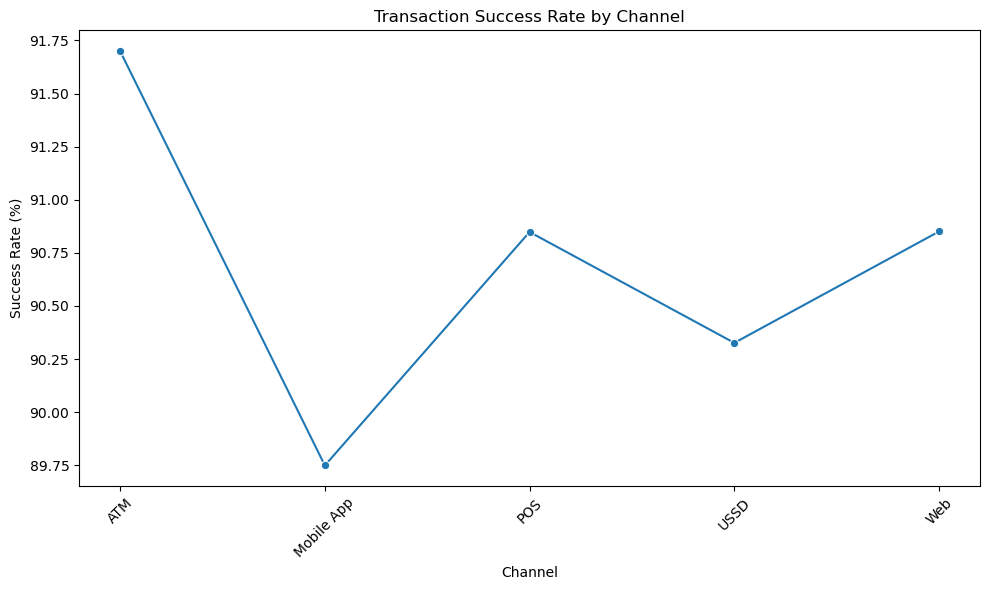

In [49]:
#Visualization
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=channel_analysis,
    x="Channel",
    y="Success_Rate",
    marker="o"
)

plt.title("Transaction Success Rate by Channel")
plt.xlabel("Channel")
plt.ylabel("Success Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
#3.International Vs Domestic
#How do international transactions compare with domestic transactions?
fintrust_df["Transaction_Scope"] = np.where(
    fintrust_df["International_Transaction"] == "Yes",
    "International",
    "Domestic"
)

In [28]:
#Summary
international_analysis = (
    fintrust_df
    .groupby("Transaction_Scope")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Total_Transaction_Value=("Amount_NGN", "sum"),
        Average_Transaction_Value=("Amount_NGN", "mean")
    )
    .reset_index()
)

In [29]:
success_scope = (
    fintrust_df[fintrust_df["Transaction_Status"] == "Successful"]
    .groupby("Transaction_Scope")["Transaction_ID"]
    .count()
    .reset_index(name="Successful_Transactions")
)

In [30]:
international_analysis = international_analysis.merge(
    success_scope,
    on="Transaction_Scope",
    how="left"
)

In [31]:
international_analysis["Success_Rate"] = (
    international_analysis["Successful_Transactions"] /
    international_analysis["Total_Transactions"] * 100
)
international_analysis

,Transaction_Scope,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value,Successful_Transactions,Success_Rate
0,Domestic,11520,5.404816e+08,46916.803036,10409,90.355903
1,International,480,1.999578e+07,41657.883063,447,93.125000


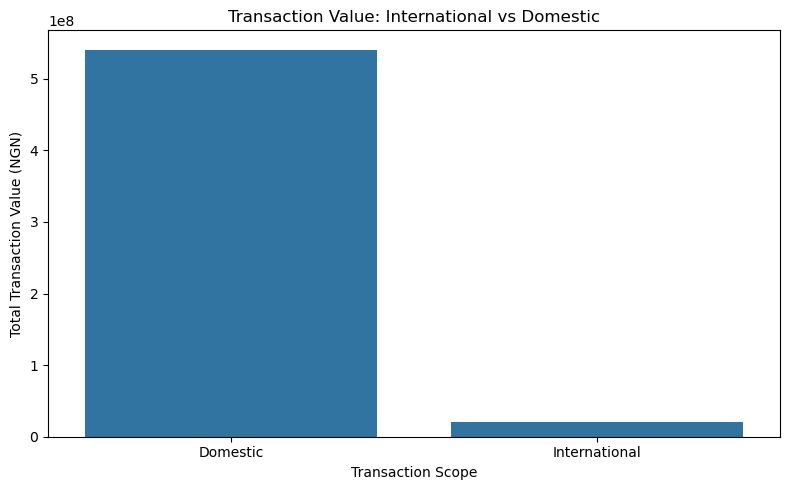

In [32]:
#Visualization
plt.figure(figsize=(8, 5))

sns.barplot(
    data=international_analysis,
    x="Transaction_Scope",
    y="Total_Transaction_Value"
)

plt.title("Transaction Value: International vs Domestic")
plt.xlabel("Transaction Scope")
plt.ylabel("Total Transaction Value (NGN)")
plt.tight_layout()
plt.show()

In [33]:
#4.Customer Activity Segmentation
#How are customers distributed according to transaction frequency?
customer_activity = (
    fintrust_df
    .groupby("Customer_ID")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Total_Transaction_Value=("Amount_NGN", "sum"),
        Average_Transaction_Value=("Amount_NGN", "mean")
    )
    .reset_index()
)

In [34]:
customer_activity["Activity_Level"] = pd.qcut(
    customer_activity["Total_Transactions"],
    q=3,
    labels=["Low Activity", "Medium Activity", "High Activity"],
    duplicates="drop"
)
customer_activity.head()

,Customer_ID,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value,Activity_Level
0,FT-C00001,7,389228.44,55604.062857,Low Activity
1,FT-C00002,5,262429.47,52485.894000,Low Activity
2,FT-C00003,2,30819.66,15409.830000,Low Activity
3,FT-C00004,9,118140.65,13126.738889,Medium Activity
4,FT-C00005,7,282577.99,40368.284286,Low Activity


In [35]:
activity_summary = (
    customer_activity
    .groupby("Activity_Level", observed=True)
    .agg(
        Total_Customers=("Customer_ID", "count"),
        Total_Transactions=("Total_Transactions", "sum"),
        Total_Transaction_Value=("Total_Transaction_Value", "sum"),
        Average_Transactions_Per_Customer=("Total_Transactions", "mean")
    )
    .reset_index()
)
activity_summary

,Activity_Level,Total_Customers,Total_Transactions,Total_Transaction_Value,Average_Transactions_Per_Customer
0,Low Activity,693,3842,1.765608e+08,5.544012
1,Medium Activity,382,3253,1.513325e+08,8.515707
2,High Activity,425,4905,2.325840e+08,11.541176


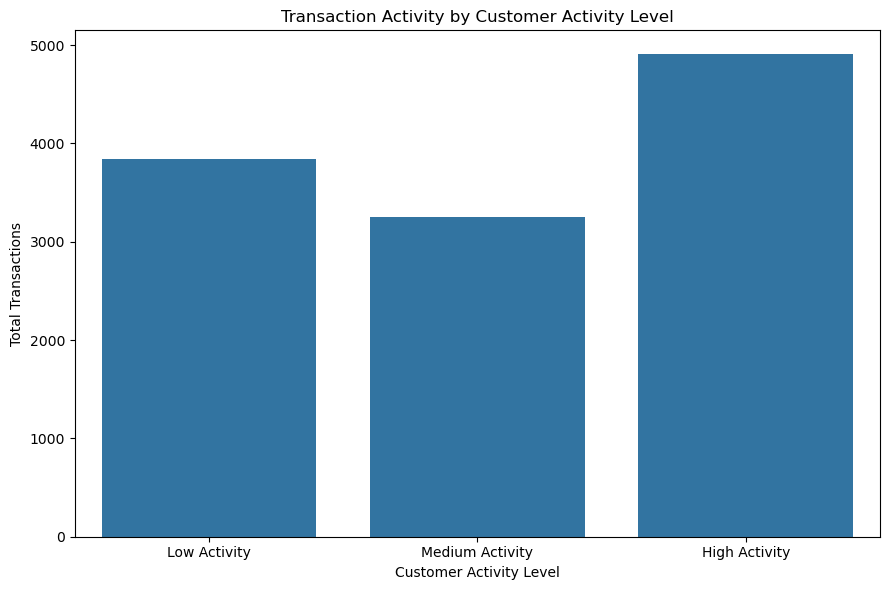

In [36]:
#Visualization
plt.figure(figsize=(9, 6))

sns.barplot(
    data=activity_summary,
    x="Activity_Level",
    y="Total_Transactions"
)

plt.title("Transaction Activity by Customer Activity Level")
plt.xlabel("Customer Activity Level")
plt.ylabel("Total Transactions")
plt.tight_layout()
plt.show()

In [37]:
#5.Risk Review
#What transaction characteristics are associated with Risk Review Flags?
risk_analysis = (
    fintrust_df
    .groupby("Risk_Review_Flag")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Total_Transaction_Value=("Amount_NGN", "sum"),
        Average_Transaction_Value=("Amount_NGN", "mean"),
        Customers_Involved=("Customer_ID", "nunique")
    )
    .reset_index()
)
risk_analysis

,Risk_Review_Flag,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value,Customers_Involved
0,No,9648,3.986937e+08,41323.976310,1498
1,Yes,2352,1.617836e+08,68785.557572,1179


In [38]:
#Compare Transaction Types
risk_type_analysis = (
    fintrust_df
    .groupby(["Risk_Review_Flag", "Transaction_Type"])
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Total_Transaction_Value=("Amount_NGN", "sum"),
        Average_Transaction_Value=("Amount_NGN", "mean")
    )
    .reset_index()
)
risk_type_analysis

,Risk_Review_Flag,Transaction_Type,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value
0,No,Airtime/Data,1005,8.296145e+06,8254.870716
1,No,Bill Payment,1286,2.454613e+07,19087.192418
2,No,Card Purchase,2638,7.243259e+07,27457.389060
3,No,Cash Withdrawal,1068,4.762790e+07,44595.414101
4,No,Deposit,1113,9.503942e+07,85390.316325
5,No,Transfer,2538,1.507515e+08,59397.766844
6,Yes,Airtime/Data,180,1.480026e+06,8222.367333
7,Yes,Bill Payment,189,3.617518e+06,19140.307196
8,Yes,Card Purchase,395,1.343082e+07,34002.079595
9,Yes,Cash Withdrawal,362,2.014446e+07,55647.679144


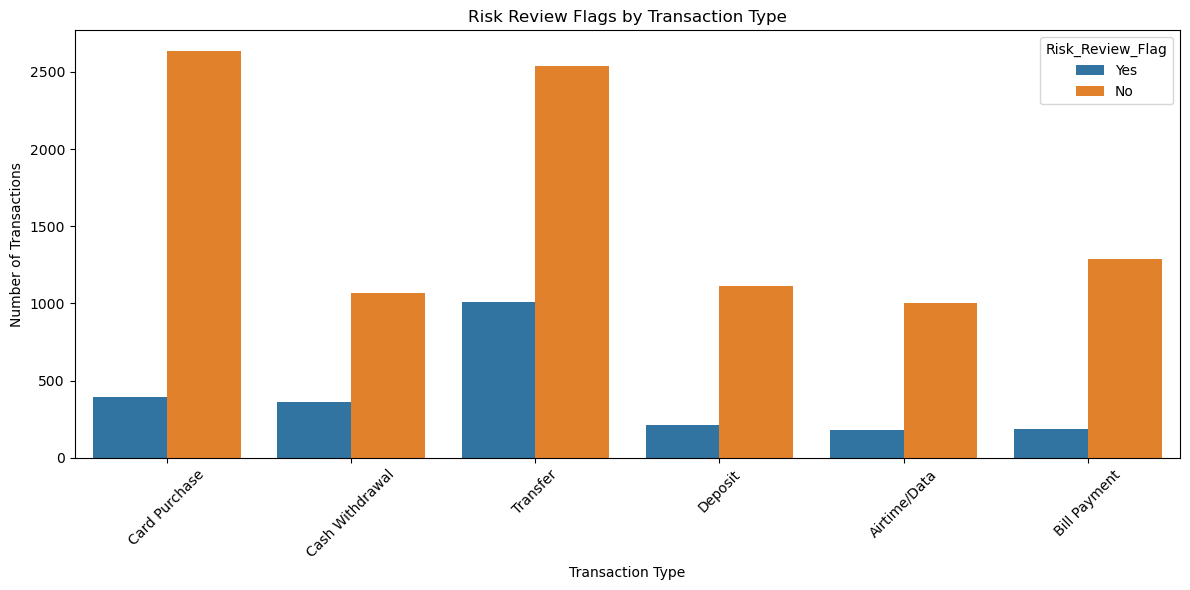

In [39]:
#Visualizations
plt.figure(figsize=(12, 6))

sns.countplot(
    data=fintrust_df,
    x="Transaction_Type",
    hue="Risk_Review_Flag"
)

plt.title("Risk Review Flags by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
#Transaction Analyis
fintrust_df["Transaction_Month"] = (
    fintrust_df["Transaction_DateTime"]
    .dt.to_period("M")
    .astype(str)
)

In [42]:
#Monthly Analysis
monthly_analysis = (
    fintrust_df
    .groupby("Transaction_Month")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Total_Transaction_Value=("Amount_NGN", "sum"),
        Average_Transaction_Value=("Amount_NGN", "mean")
    )
    .reset_index()
)
monthly_analysis

,Transaction_Month,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value
0,2026-01,4133,1.884894e+08,45605.960486
1,2026-02,3734,1.757869e+08,47077.369306
2,2026-03,4133,1.962010e+08,47471.817849


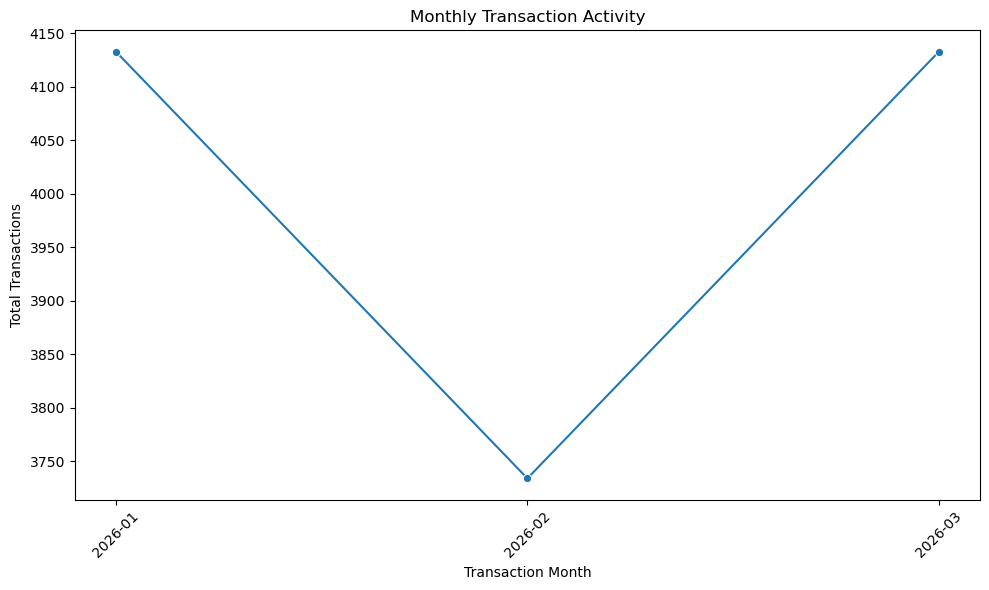

In [43]:
#Visualization
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=monthly_analysis,
    x="Transaction_Month",
    y="Total_Transactions",
    marker="o"
)

plt.title("Monthly Transaction Activity")
plt.xlabel("Transaction Month")
plt.ylabel("Total Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()